In [ ]:
# importing base libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [ ]:
# importing required libraries to build a cnn model
import tensorflow as tf
from tensorflow.keras.layers import Input , Conv2D , MaxPooling2D , Flatten , Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
# loading the data
(train_data , train_labels) , (test_data , test_labels) = fashion_mnist.load_data()


In [ ]:
# exploring the shapes of the data
print(f'the shape of the train data is {train_data.shape}')
print(f'the shape of the test data is {test_data.shape}')
print(f'the shape of the train labels is {train_labels.shape}')
print(f'the shape of the test labels is {test_labels.shape}')

the shape of the train data is (60000, 28, 28)
the shape of the test data is (10000, 28, 28)
the shape of the train labels is (60000,)
the shape of the test labels is (10000,)


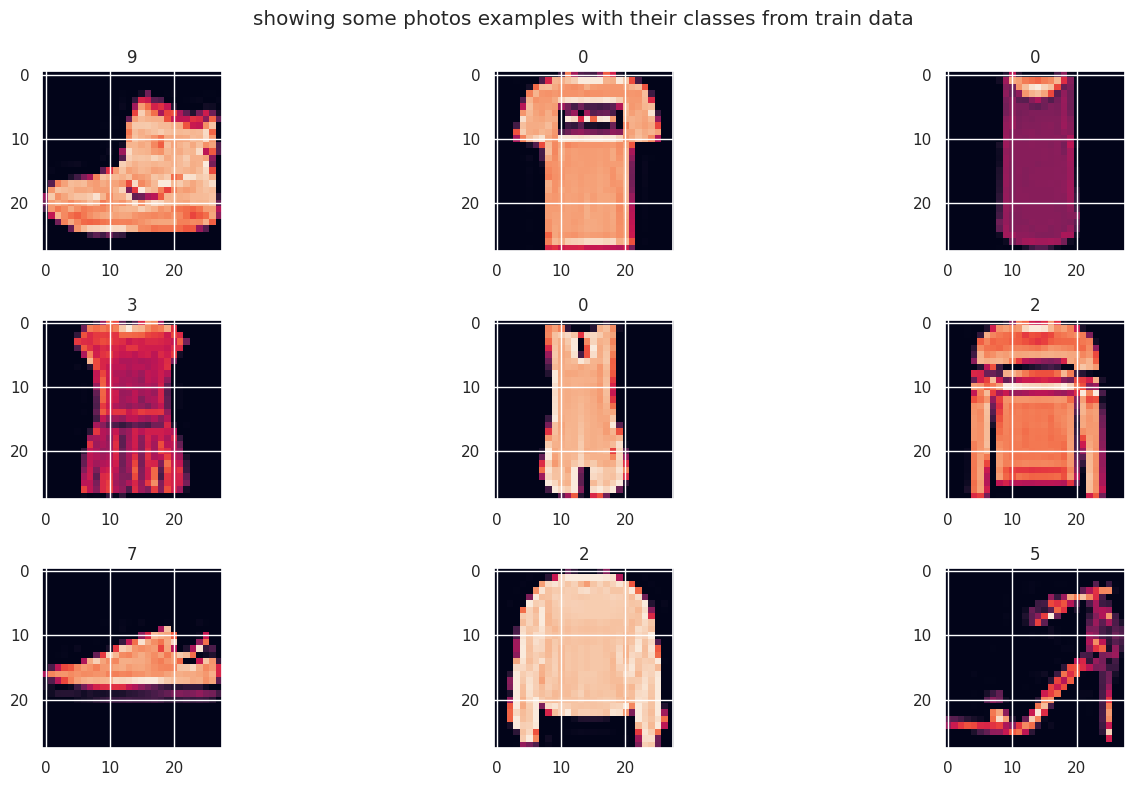

In [ ]:
# printing some samples from the images with their classes
fig=1
plt.figure(figsize=(15,8))
plt.suptitle('showing some photos examples with their classes from train data')
for index in range(9):
  plt.subplot(3,3,fig)
  plt.imshow(train_data[index])
  plt.title(train_labels[index])
  fig +=1
plt.tight_layout()
plt.show()


In [ ]:
# getting the dimensions for all the images
dimensions = []
for img in train_data :
  dimensions.append(img.shape)
print(set(dimensions))

{(28, 28)}


In [ ]:
# reshaping the train and test images
train_data.reshape(-1 , 28,28,1)
test_data.reshape(-1 , 28,28,1)

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [ ]:
# sharpning the images
import cv2
sharpening_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpend_train = np.empty_like(train_data)
sharpend_test = np.empty_like(test_data)
for index in range(60000) :
  sharpend_train[index] = cv2.filter2D(train_data[index].squeeze(), -1, sharpening_kernel)

for index in range(10000) :
  sharpend_test[index] = cv2.filter2D(test_data[index].squeeze(), -1, sharpening_kernel)


In [ ]:
# scaling the images
for index in range(60000) :
  sharpend_train[index] = sharpend_train[index] / 255

for index in range(10000) :
  sharpend_test[index] = sharpend_test[index] / 255

In [ ]:
# encoding the target labels
num_of_classes = len(set(train_labels))
print(f' the number of classes in teh target column = {num_of_classes}')
train_labels_encoded =to_categorical(train_labels , num_classes= num_of_classes)
test_labels_encoded = to_categorical(test_labels , num_classes= num_of_classes)

 the number of classes in teh target column = 10


In [ ]:
# printing the first 10 encoded vectors
train_labels_encoded[0:10]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

In [ ]:
# building the cnn model and addind regularization to prevent it from overfitting
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

input = Input(shape=(28,28,1) )
cnn = Conv2D(32, (2, 2), padding='same', activation='relu', kernel_regularizer=l2(0.001))(input)
cnn = MaxPooling2D((2, 2))(cnn)


cnn = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01))(cnn)
cnn = MaxPooling2D((3, 3))(cnn)


cnn = Flatten()(cnn)
cnn = Dense(64, activation='relu')(cnn)
cnn = Dropout(0.3)(cnn)
cnn = Dense(32, activation='relu')(cnn)
output = Dense(10, activation='softmax')(cnn)
model = Model(inputs = input , outputs = output)

In [ ]:
# printing model summary
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,666 (338.54 KB)

 Trainable params: 86,666 (338.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compiling the model
model.compile(optimizer='adam' , loss = 'categorical_crossentropy' , metrics=['accuracy'])

In [ ]:
# fitting the model on the data
history = model.fit(sharpend_train , train_labels_encoded , batch_size=128 , epochs = 15 , validation_split=0.1)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5670 - loss: 1.3598 - val_accuracy: 0.7928 - val_loss: 0.6083
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7799 - loss: 0.6545 - val_accuracy: 0.8217 - val_loss: 0.5353
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8103 - loss: 0.5705 - val_accuracy: 0.8407 - val_loss: 0.4821
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8255 - loss: 0.5365 - val_accuracy: 0.8512 - val_loss: 0.4675
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8372 - loss: 0.4972 - val_accuracy: 0.8552 - val_loss: 0.4500
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8386 - loss: 0.4910 - val_accuracy: 0.8533 - val_loss: 0.4455
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8432 - loss: 0.4765 - val_accuracy: 0.8572 - val_loss: 0.4341
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8478 - loss: 0.4647 - val_accuracy: 0

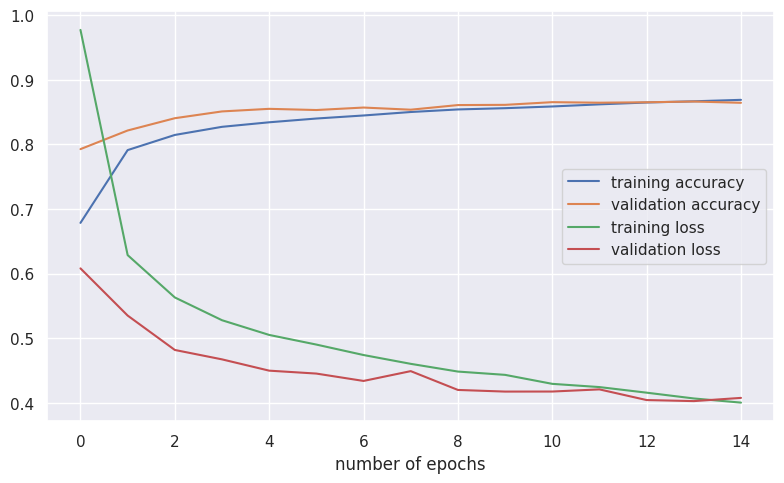

In [ ]:
# plotting model training accuracy and validation
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'] , label ='training accuracy')
plt.plot(history.history['val_accuracy'] , label= 'validation accuracy')
plt.plot(history.history['loss'] , label ='training loss')
plt.plot(history.history['val_loss'] , label = 'validation loss')
plt.xlabel('number of epochs')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# printing model accuracy over training data
model.evaluate(sharpend_train , train_labels_encoded)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8910 - loss: 0.3387


[0.34795287251472473, 0.8881833553314209]

In [ ]:
# printing model accuracy over test data
model.evaluate(sharpend_test , test_labels_encoded)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8695 - loss: 0.4052


[0.41184571385383606, 0.866599977016449]

- i've tried different epochs numbers , batch size , adding drop out and using l2 regularization but the above model with the least overfitted one despit of the accuracy value